# Generating greain boundary zones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.pxtal.vortess2d import gtess2d

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


## generate base grain structure

In [2]:
from upxo.pxtal.vortess2d import gtess2d
repr_prop={'area': {'mean': {'val': 50, 'dev': 5.0,},
                    'consider_boundary_grains': True},}
gset = gtess2d.from_seed_points(sp_input='gen', xbound=[0, 100],
         ybound = [0, 60], sp_distr='random', gr_tech='pds',
         smp_tech='bridson1', lean='veryhigh', char_length=[4.5],
         ntp=25, ntrials=100, n_instances=1, repr_prop=repr_prop,
         k_char_length_inc=0.05, k_char_length_dec=0.05,)


Generating pxtal. Iteration 1
No. of seed points: 312
Generating pxtal. Iteration 2
No. of seed points: 313
Generating pxtal. Iteration 3
No. of seed points: 266
Generating pxtal. Iteration 4
No. of seed points: 242
Generating pxtal. Iteration 5
No. of seed points: 237
Generating pxtal. Iteration 6
No. of seed points: 215
Generating pxtal. Iteration 7
No. of seed points: 195
Generating pxtal. Iteration 8
No. of seed points: 181
Generating pxtal. Iteration 9
No. of seed points: 162
Generating pxtal. Iteration 10
No. of seed points: 157
Generating pxtal. Iteration 11
No. of seed points: 143
Generating pxtal. Iteration 12
No. of seed points: 138
Generating pxtal. Iteration 13
No. of seed points: 128
Generating pxtal. Iteration 14
No. of seed points: 119
----------------------------------------
Grain structure search converged in 13 iterations
Sample set parent found.
----
Target mean grain area: 50
Sample mean grain area: 50.420168
----
Input Char. length: [4.5]
Final Char. length: [7.2]


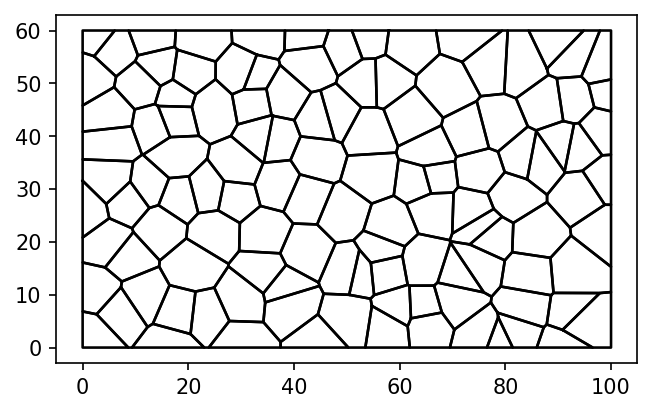

In [3]:
plt.figure(figsize=(5, 5), dpi=150)
coords_cid = [np.vstack(c.boundary.xy).T for c in gset.pxtals[1].geoms]
for vc in coords_cid:
    plt.plot(vc[:, 0], vc[:, 1], '-k', linewidth=1.25)
plt.gca().set_aspect('equal')

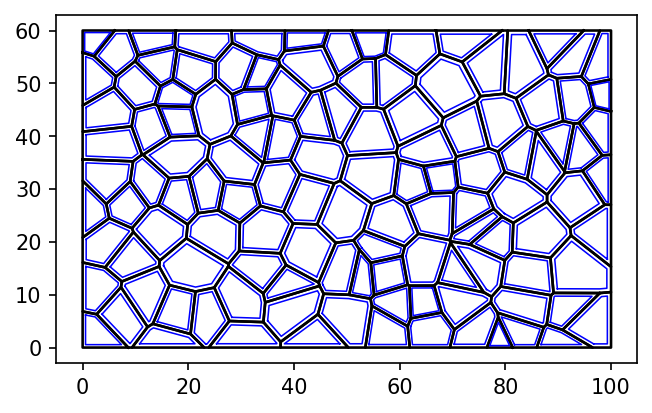

In [4]:
zones = gset.sf_gbz(instance=1, gslevel='base', 
                    k_shr=0.10,
                    assemble_cells=True, 
                    saa=True, throw=False, viz=True)


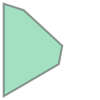

In [5]:
pcid = 0
# This is the 1st parent grain, i.e. 1st base cell.
gset.pxtals[1].geoms[pcid]

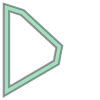

In [6]:
# This is the boundary zones of the 1st base cell.
zones['cbz'][pcid]  # 2

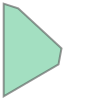

In [7]:
# This is the core zone of the 1st base cell.
zones['ccz'][pcid]  # 2

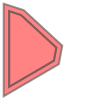

In [8]:
# This is multi-cell: zones['cbz'][pcid] + zones['ccz'][pcid]
zones['sf_pcwise'][pcid]  # 3

#### access individual geometry of multi-cell

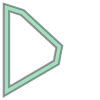

In [9]:
zones['sf_pcwise'][pcid][0]  # 4  <-- subfeature 1

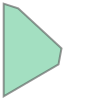

In [10]:
zones['sf_pcwise'][pcid][1]  # 5  <-- subfeature 2

#### Alternatively, you can also access the same as belw9

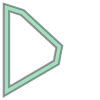

In [11]:
zones['sf_pcwise'][pcid].geoms[0]  # 6  <-- subfeature 1

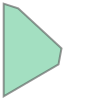

In [12]:
zones['sf_pcwise'][pcid].geoms[1]  # 7  <-- subfeature 2

Note: 4 and 5 is same as 6 and 7 resepectively.

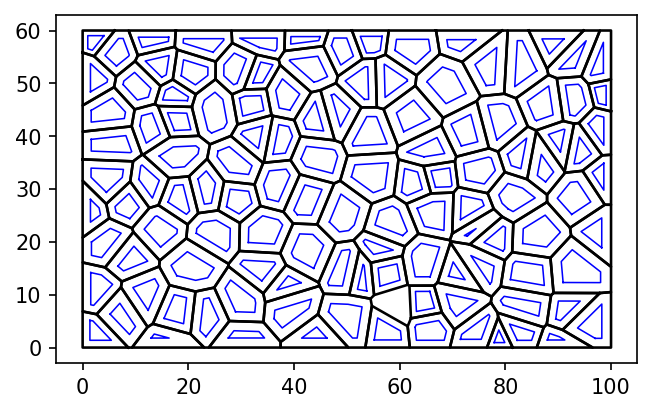

In [13]:
zones = gset.sf_gbz(instance=1, gslevel='base', 
                    k_shr=0.25,
                    assemble_cells=True, 
                    saa=True, throw=False, viz=True)
